In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/34_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/40_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/22_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/27_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/28_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/26_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/38_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/39_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/24_training.tif
/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/tr

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.filters import threshold_niblack, threshold_sauvola
from skimage import img_as_ubyte
from skimage.morphology import skeletonize
import os

In [15]:
BASE = '/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE'

In [16]:
image_dir = f'{BASE}/training/images'
mask_dir = f'{BASE}/training/1st_manual'

lets pick the first image

In [17]:
img_file = sorted(os.listdir(image_dir))[0]
mask_file = sorted(os.listdir(mask_dir))[0]
print(img_file)
print(mask_file)

21_training.tif
21_manual1.gif


In [18]:
type(img_file)

str

In [19]:
img_bgr = cv2.imread(os.path.join(image_dir,img_file))
gt_mask = cv2.imread(os.path.join(mask_dir,mask_file),cv2.IMREAD_GRAYSCALE)
print(f"{img_bgr.shape}")
print(f"{gt_bgr.shape}")

(584, 565, 3)
(584, 565)


# Preprocessing

In [20]:
# Using Green channel — best contrast for vessels in fundus images
green = img_bgr[:, :,1]

# CLAHE — contrast limited adaptive histogram equalization
clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
green_eq = clahe.apply(green)

# Invert so vessels are bright (Niblack/Sauvola threshold bright objects)
green_inv = cv2.bitwise_not(green_eq)

# Niblack Thresholding

In [21]:
window_size = 25  
k_niblack   = 0.2

thresh_niblack = threshold_niblack(green_inv, window_size=window_size, k=k_niblack)
binary_niblack = (green_inv > thresh_niblack).astype(np.uint8) * 255

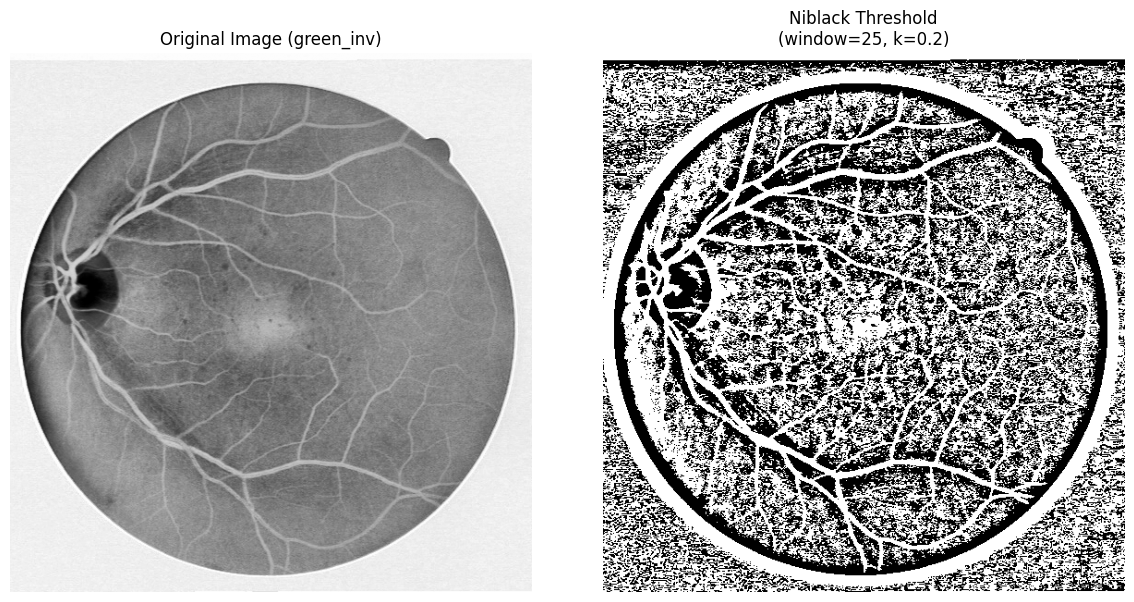

In [33]:

plt.figure(figsize=(12, 6))

# Plot the original image (green_inv)
plt.subplot(1, 2, 1)
plt.imshow(green_inv, cmap='gray') # cmap='gray' is important for single-channel images
plt.title('Original Image (green_inv)')
plt.axis('off') # Hides the x and y axes

# Plot the Niblack binary result
plt.subplot(1, 2, 2)
plt.imshow(binary_niblack, cmap='gray')
plt.title(f'Niblack Threshold\n(window={window_size}, k={k_niblack})')
plt.axis('off')

# Display the plots
plt.tight_layout()
plt.show()

### Niblack

Both Niblack and Sauvola are **local (or adaptive) thresholding** techniques. Instead of calculating a single global threshold for the entire image, they compute a unique threshold for each pixel based on the local mean ($\mu$) and local standard deviation ($\sigma$) of the pixels within a specified neighborhood (e.g., `window_size = 25`).

#### 1. Niblack Thresholding
The Niblack algorithm calculates the threshold using the following formula:
$$T = \mu + k \cdot \sigma$$

* **Observation:** In the Niblack result, the blood vessels is captured very well. However, there is a massive amount of noise in the background.



# Sauvola Thresholding

In [22]:
k_sauvola = 0.2
r_sauvola  = 128

thresh_sauvola = threshold_sauvola(green_inv, window_size=window_size,
                                    k=k_sauvola, r=r_sauvola)
binary_sauvola = (green_inv > thresh_sauvola).astype(np.uint8) * 255

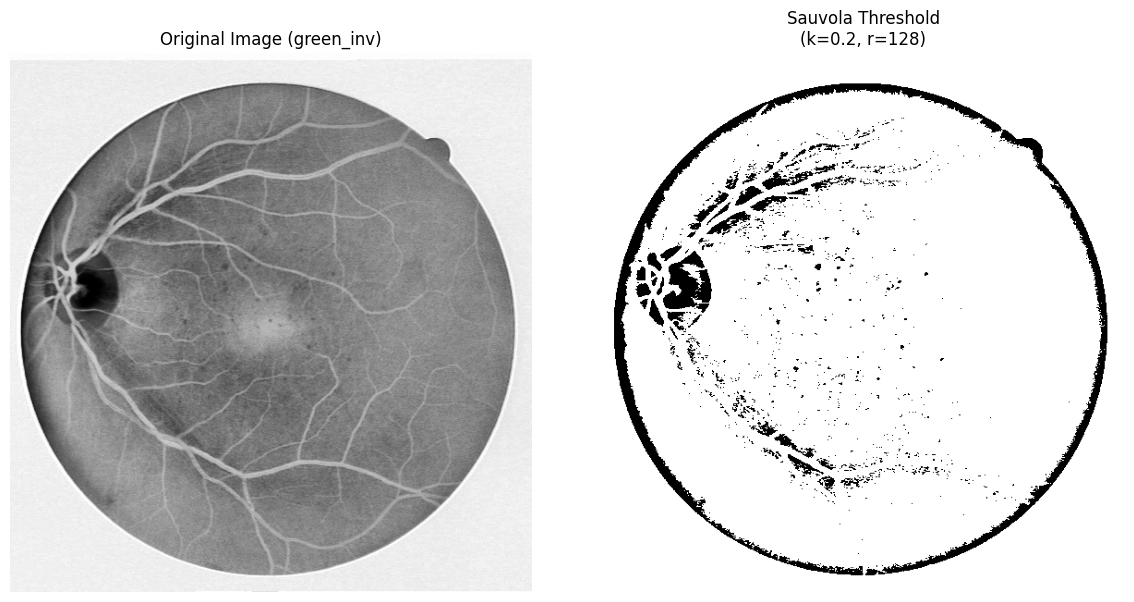

In [30]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(green_inv, cmap='gray') 
plt.title('Original Image (green_inv)')
plt.axis('off') 

# Niblack binary result
plt.subplot(1, 2, 2)
plt.imshow(binary_sauvola, cmap='gray')
plt.title(f'Sauvola Threshold\n(k={k_sauvola}, r={r_sauvola})')
plt.axis('off')

plt.tight_layout()
plt.show()

#### 2. Sauvola Thresholding
The Sauvola algorithm is an improvement over Niblack, designed specifically to address the background noise issue. It introduces a dynamic range parameter $R$ (often 128 for 8-bit images):
$$T = \mu \cdot \left[1 + k \cdot \left(\frac{\sigma}{R} - 1\right)\right]$$

* **Observation:** The Sauvola result has a beautifully clean background, with almost all the noise completely suppressed. However, some of the fainter, thinner vessels have been lost compared to the Niblack result.


#### Summary
* **Niblack:** High sensitivity to fine details, but highly susceptible to background noise in low-contrast regions.
* **Sauvola:** Excellent at suppressing background noise, but less sensitive to faint, low-contrast features.

# Post-processing (remove small noise blobs)

In [23]:
def clean_binary(img, min_area=30):
    nb_components, output, stats, _ = cv2.connectedComponentsWithStats(img, connectivity=8)
    cleaned = np.zeros_like(img)
    for i in range(1, nb_components):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[output == i] = 255
    return cleaned

niblack_clean = clean_binary(binary_niblack)
sauvola_clean = clean_binary(binary_sauvola)

# Sensitivity for Thin Vessel

In [24]:
# "Thin vessels" = skeletonized ground truth (1-pixel wide centerlines)
gt_binary   = (gt_mask > 127).astype(np.uint8)
gt_skeleton = skeletonize(gt_binary).astype(np.uint8)  # thin vessel map

def sensitivity(pred_binary, gt_thin):
    """True Positive Rate on thin vessel pixels only."""
    pred = (pred_binary > 127).astype(np.uint8)
    tp = np.sum((pred == 1) & (gt_thin == 1))
    fn = np.sum((pred == 0) & (gt_thin == 1))
    return tp / (tp + fn + 1e-8)

sens_niblack = sensitivity(niblack_clean, gt_skeleton)
sens_sauvola = sensitivity(sauvola_clean, gt_skeleton)

print(f"\n{'Method':<12} {'Thin-Vessel Sensitivity':>25}")
print("-" * 40)
print(f"{'Niblack':<12} {sens_niblack:>25.4f}")
print(f"{'Sauvola':<12} {sens_sauvola:>25.4f}")


Method         Thin-Vessel Sensitivity
----------------------------------------
Niblack                         0.9509
Sauvola                         0.9817


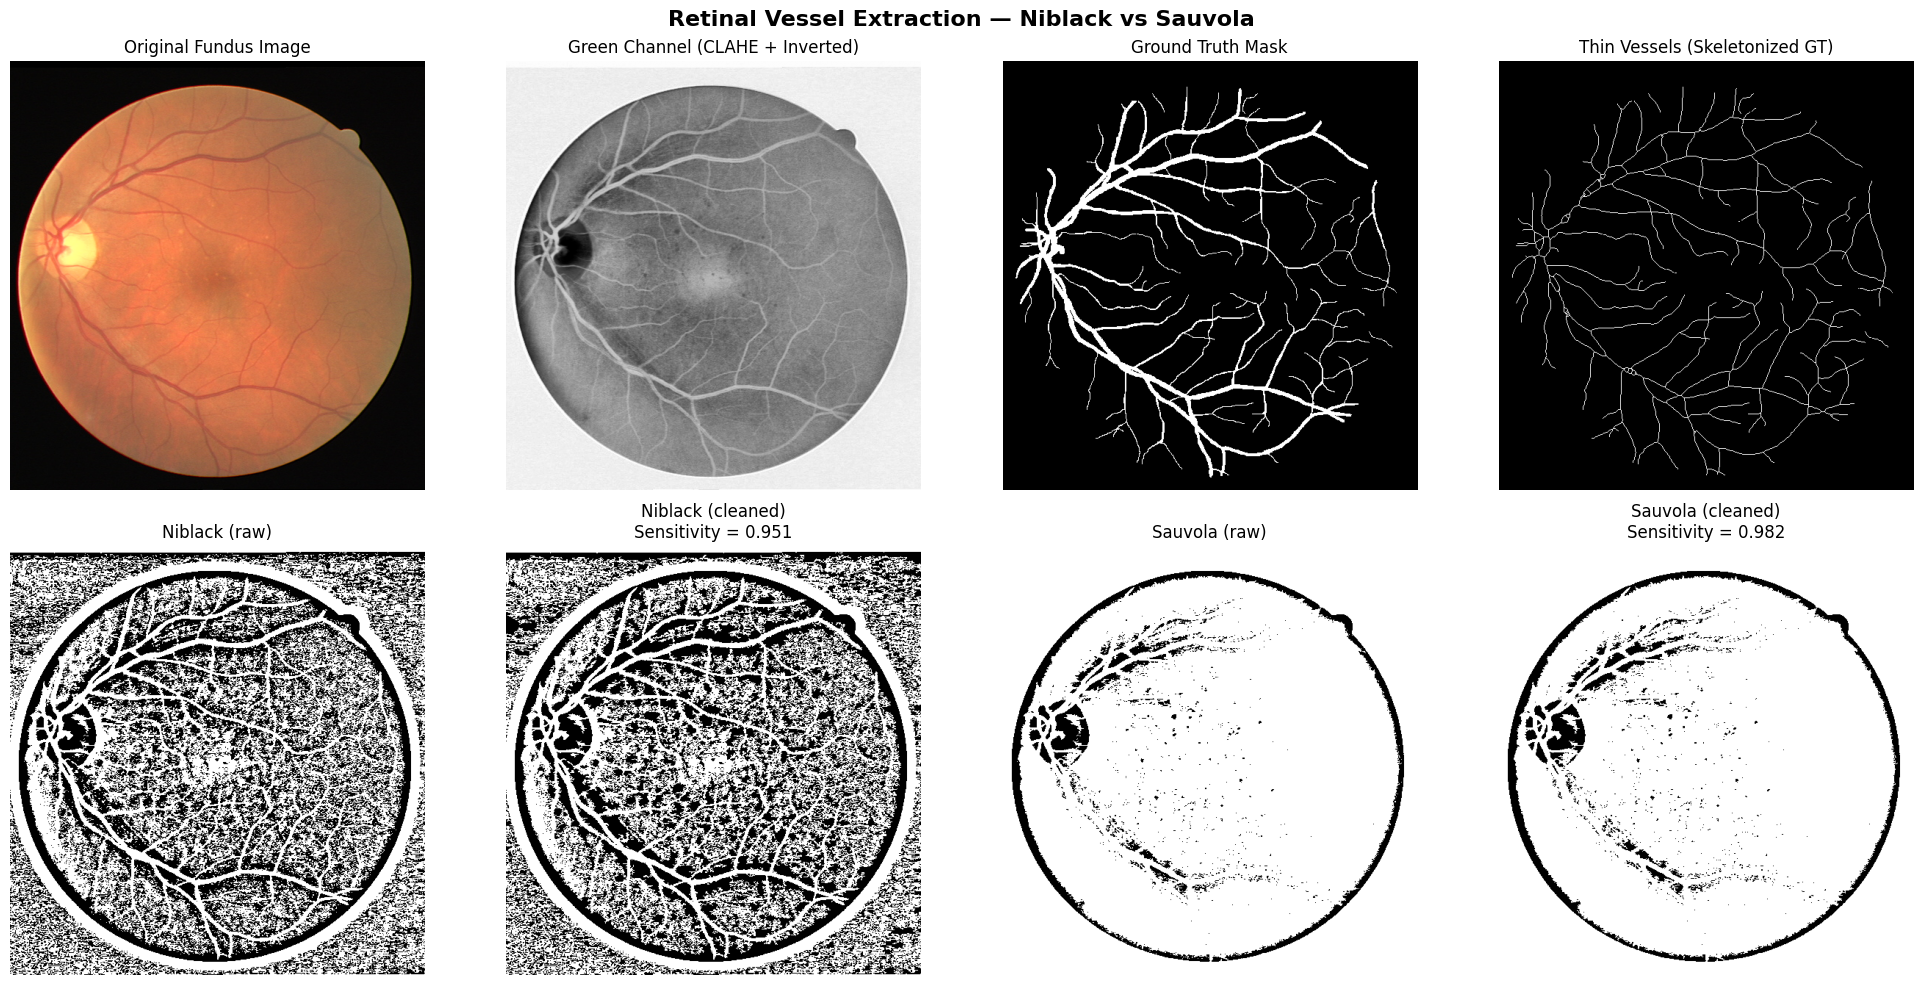

In [35]:
# Plot 1: Overview of all processing stages

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Retinal Vessel Extraction — Niblack vs Sauvola', fontsize=16, fontweight='bold')

# Row 1: input data and ground truth
axes[0, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Fundus Image')

axes[0, 1].imshow(green_inv, cmap='gray')
axes[0, 1].set_title('Green Channel (CLAHE + Inverted)')

axes[0, 2].imshow(gt_mask, cmap='gray')
axes[0, 2].set_title('Ground Truth Mask')

axes[0, 3].imshow(gt_skeleton, cmap='gray')
axes[0, 3].set_title('Thin Vessels (Skeletonized GT)')

# Row 2: thresholding results
axes[1, 0].imshow(binary_niblack, cmap='gray')
axes[1, 0].set_title('Niblack (raw)')

axes[1, 1].imshow(niblack_clean, cmap='gray')
axes[1, 1].set_title(f'Niblack (cleaned)\nSensitivity = {sens_niblack:.3f}')

axes[1, 2].imshow(binary_sauvola, cmap='gray')
axes[1, 2].set_title('Sauvola (raw)')

axes[1, 3].imshow(sauvola_clean, cmap='gray')
axes[1, 3].set_title(f'Sauvola (cleaned)\nSensitivity = {sens_sauvola:.3f}')

# turn off axis ticks for all subplots
for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig('niblack_vs_sauvola.png', dpi=150, bbox_inches='tight')
plt.show()

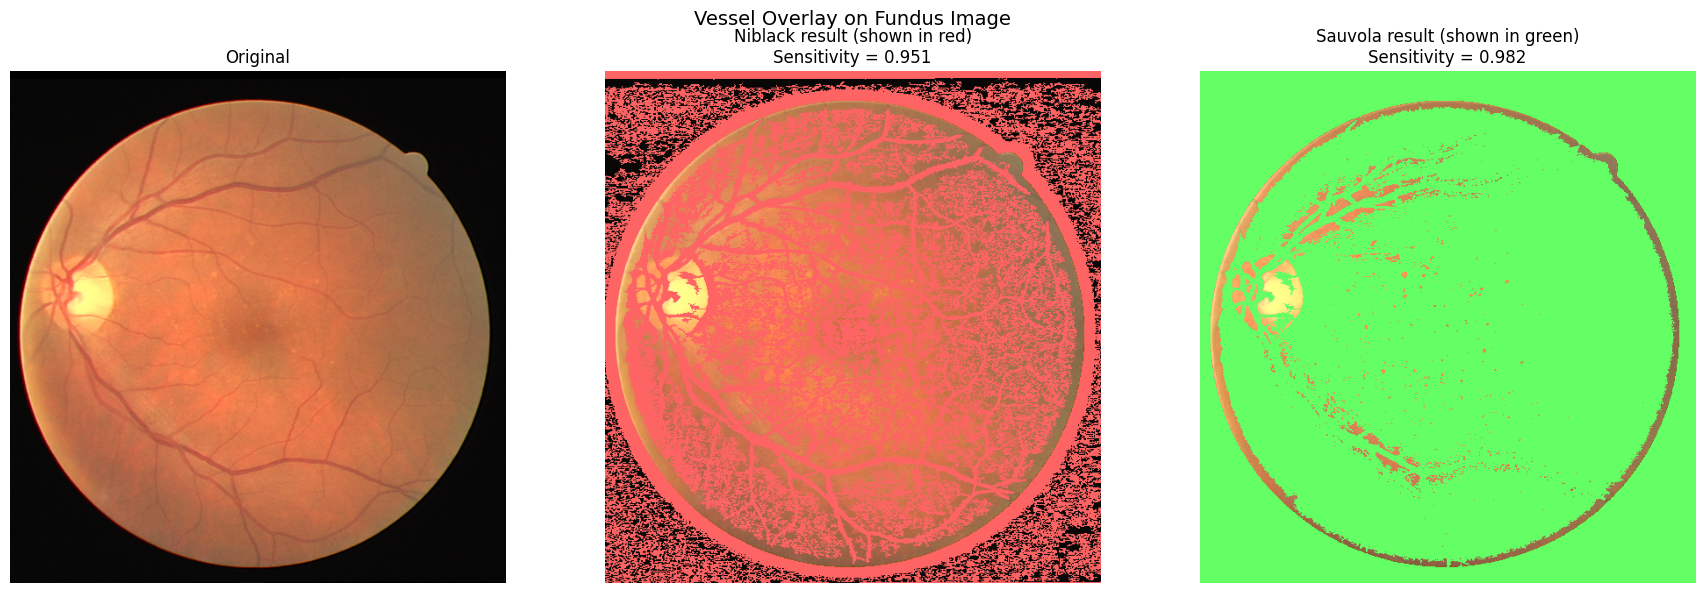

In [36]:
# --- Plot 2: Overlay extracted vessels on top of the original image ---
# This helps visually judge where each method is detecting vessels

def overlay_vessels(base_img, vessel_mask, color):
    output = base_img.copy()
    # wherever the mask says "vessel", paint it with the chosen color
    output[vessel_mask > 127] = color
    return output

orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# red tint for Niblack, green tint for Sauvola — easy to compare side by side
niblack_overlay = overlay_vessels(orig_rgb.copy(), niblack_clean, color=(255, 100, 100))
sauvola_overlay = overlay_vessels(orig_rgb.copy(), sauvola_clean, color=(100, 255, 100))

fig2, ax2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Vessel Overlay on Fundus Image', fontsize=14)

ax2[0].imshow(orig_rgb)
ax2[0].set_title('Original')

ax2[1].imshow(niblack_overlay)
ax2[1].set_title(f'Niblack result (shown in red)\nSensitivity = {sens_niblack:.3f}')

ax2[2].imshow(sauvola_overlay)
ax2[2].set_title(f'Sauvola result (shown in green)\nSensitivity = {sens_sauvola:.3f}')

for a in ax2:
    a.axis('off')

plt.tight_layout()
plt.show()

### Conclusion
Evaluation tells that Sauvola outperforms Niblack in thin-vessel sensitivity (0.9817 vs. 0.9509). While Niblack visually appeared to capture fine details, its severe background noise likely introduces FP that degrade its statistical accuracy. Sauvola’s dynamic range adaptation effectively suppresses this noise, proving that a cleaner background ultimately yields a more accurate segmentation.